In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# Optimisation Mac M1
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Utilisation du device : {device}")

Utilisation du device : mps


In [14]:
class TemporalEncoder(nn.Module):
    def __init__(self, context_dim=256):
        super().__init__()
        # Extraction de caractéristiques spatiales (CNN)
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.SiLU(),
            nn.AdaptiveAvgPool2d((4, 4)) # Réduction pour le LSTM
        )
        # Analyse temporelle
        self.lstm = nn.LSTM(64 * 4 * 4, context_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(context_dim * 2, context_dim)

    def forward(self, x):
        # x shape: (batch, seq_len, 2, 32, 32)
        batch_size, seq_len, c, h, w = x.shape
        
        # On regroupe batch et seq_len pour passer dans le CNN
        # Utilisation de reshape au lieu de view pour la sécurité sur M1
        x = x.reshape(batch_size * seq_len, c, h, w)
        
        features = self.feature_extractor(x) # Sortie du CNN

        features = features.contiguous().reshape(batch_size, seq_len, -1)
        
        _, (hn, _) = self.lstm(features)
        
        # Concaténation des deux directions du Bi-LSTM
        # hn shape: (num_layers * num_directions, batch, hidden_size)
        out = torch.cat((hn[0], hn[1]), dim=1).contiguous()
        
        return self.fc(out)

In [15]:
class DiffusionUNet(nn.Module):
    def __init__(self, context_dim=256):
        super().__init__()
        self.context_dim = context_dim
        
        # 1. Embedding du temps t
        self.time_mlp = nn.Sequential(
            nn.Linear(1, context_dim),
            nn.SiLU(),
            nn.Linear(context_dim, context_dim)
        )
        
        # 2. Projection du contexte spatial (32x32)
        self.ctx_projection = nn.Linear(context_dim, 32 * 32)
        
        # 3. Encoder (Descente)
        self.enc1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)  # 32x32
        self.enc2 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1) # 16x16
        self.enc3 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1) # 8x8
        self.enc4 = nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1) # 4x4
        
        # 4. Bottleneck (Le point le plus profond)
        self.bottleneck = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.time_proj_deep = nn.Linear(context_dim, 512)
        
        # 5. Decoder (Remontée avec Skip Connections)
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1) # 8x8
        self.up2 = nn.ConvTranspose2d(512, 128, kernel_size=4, stride=2, padding=1) # 16x16 (256 up + 256 skip)
        self.up3 = nn.ConvTranspose2d(256, 64, kernel_size=4, stride=2, padding=1)  # 32x32 (128 up + 128 skip)
        
        # Sortie finale : up3(64) + enc1(64) = 128
        self.final = nn.Conv2d(128, 2, kernel_size=3, padding=1) 

    def forward(self, x, context, t):
        # Embeddings
        t_hidden = self.time_mlp(t)
        t_deep = self.time_proj_deep(t_hidden).contiguous().reshape(-1, 512, 1, 1)
        ctx_map = self.ctx_projection(context).contiguous().reshape(-1, 1, 32, 32)
        
        # ENCODER
        x_in = torch.cat([x, ctx_map.contiguous()], dim=1) # (B, 3, 32, 32)
        
        h1 = F.silu(self.enc1(x_in)) # 32x32
        h2 = F.silu(self.enc2(h1))   # 16x16
        h3 = F.silu(self.enc3(h2))   # 8x8
        h4 = F.silu(self.enc4(h3))   # 4x4
        
        # BOTTLENECK
        h4 = F.silu(self.bottleneck(h4))
        h4 = h4 + t_deep # Injection du temps au plus profond
        
        # DECODER (avec Skip Connections)
        # Niveau 1 (8x8)
        out = F.silu(self.up1(h4))
        out = torch.cat([out, h3], dim=1) # Concatène 256 + 256
        
        # Niveau 2 (16x16)
        out = F.silu(self.up2(out))
        out = torch.cat([out, h2], dim=1) # Concatène 128 + 128
        
        # Niveau 3 (32x32)
        out = F.silu(self.up3(out))
        out = torch.cat([out, h1], dim=1) # Concatène 64 + 64
        
        return self.final(out)

In [16]:
def train_step(encoder, unet, optimizer, x_past, y_future, steps=100):
    encoder.train()
    unet.train()
    optimizer.zero_grad()
    
    batch_size = y_future.shape[0]
    context = encoder(x_past)
    
    # Diffusion forward
    t = torch.rand(batch_size, 1, device=device)
    noise = torch.randn_like(y_future)
    
    # Schedule linéaire : y_noisy = sqrt(alpha)*y + sqrt(1-alpha)*noise
    alpha = 1.0 - t
    y_noisy = torch.sqrt(alpha).view(-1,1,1,1) * y_future + torch.sqrt(1-alpha).view(-1,1,1,1) * noise
    
    # Prédiction
    pred_y = unet(y_noisy, context, t)
    
    # Huber Loss (robuste aux outliers du canal wireless)
    loss = F.huber_loss(pred_y, y_future)
    
    loss.backward()
    optimizer.step()
    return loss.item()

In [17]:
@torch.no_grad()
def predict_csi(encoder, unet, x_past, n_steps=100):
    encoder.eval()
    unet.eval()
    
    context = encoder(x_past)
    # Partir d'un bruit pur Gaussien
    y_t = torch.randn(x_past.shape[0], 2, 32, 32).to(device)
    
    # Dénoyage itératif
    for i in reversed(range(n_steps)):
        t = torch.tensor([[i / n_steps]], device=device).repeat(x_past.shape[0], 1)
        y_t = unet(y_t, context, t)
        
    return y_t

In [18]:
# 1. Création des instances
encoder = TemporalEncoder(context_dim=256).to(device)
unet = DiffusionUNet(context_dim=256).to(device)

# 2. Définition de l'optimiseur (Adam est recommandé dans l'article)
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(unet.parameters()), 
    lr=1e-4
)

print("Modèles chargés sur le processeur M1.")

Modèles chargés sur le processeur M1.


In [19]:
from torch.utils.data import Dataset, DataLoader

# --- ÉTAPE 1 : Calcul des stats sur les fichiers BRUTS ---
# On charge les fichiers une seule fois pour extraire la moyenne et l'écart-type
x_raw_train = np.load("./../Data_format/X_train.npy")
y_raw_train = np.load("./../Data_format/Y_train.npy")

X_MEAN, X_STD = x_raw_train.mean(), x_raw_train.std()
Y_MEAN, Y_STD = y_raw_train.mean(), y_raw_train.std()

print(f"Stats calculées - X_mean: {X_MEAN:.4f}, Y_mean: {Y_MEAN:.4f}")

# --- ÉTAPE 2 : Classe Dataset corrigée ---
class CSIDataset(Dataset):
    def __init__(self, x_path, y_path):
        # On charge les données dans l'init
        self.x_data = np.load(x_path) 
        self.y_data = np.load(y_path)
        
    def __len__(self):
        return len(self.x_data)
    
    def __getitem__(self, idx):
        # Normalisation en utilisant les constantes globales
        x_norm = (self.x_data[idx] - X_MEAN) / X_STD
        y_norm = (self.y_data[idx] - Y_MEAN) / Y_STD
        
        # Conversion Torch + Permute (N, C, H, W)
        x_tensor = torch.from_numpy(x_norm).float().permute(0, 3, 1, 2)
        y_tensor = torch.from_numpy(y_norm).float().permute(2, 0, 1)
        
        return x_tensor, y_tensor

# --- ÉTAPE 3 : Création des instances ---
train_dataset = CSIDataset("./../Data_format/X_train.npy", "./../Data_format/Y_train.npy")
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = CSIDataset("./../Data_format/X_test.npy", "./../Data_format/Y_test.npy")

Stats calculées - X_mean: 0.4996, Y_mean: 0.4996


In [20]:
# Initialisation des modèles et de l'optimiseur (si ce n'est pas déjà fait)
encoder = TemporalEncoder(context_dim=256).to(device)
unet = DiffusionUNet(context_dim=256).to(device)
optimizer = torch.optim.AdamW(list(encoder.parameters()) + list(unet.parameters()), lr=2e-4)

EPOCHS = 30 # Ajustez selon le temps imparti

print(f"Entraînement lancé sur {device}...")

for epoch in range(EPOCHS):
    total_loss = 0
    for x_batch, y_batch in train_loader:
        # Envoi des données sur le GPU M1 (MPS)
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        
        # Utilisation de la fonction train_step que vous avez déjà dans le notebook
        loss = train_step(encoder, unet, optimizer, x_batch, y_batch)
        total_loss += loss
        
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {avg_loss:.6f}")

Entraînement lancé sur mps...
Epoch [1/30] - Loss: 0.092898
Epoch [2/30] - Loss: 0.056861
Epoch [3/30] - Loss: 0.051774
Epoch [4/30] - Loss: 0.049451
Epoch [5/30] - Loss: 0.047550
Epoch [6/30] - Loss: 0.045971
Epoch [7/30] - Loss: 0.045921
Epoch [8/30] - Loss: 0.043948
Epoch [9/30] - Loss: 0.043868
Epoch [10/30] - Loss: 0.041858
Epoch [11/30] - Loss: 0.041873
Epoch [12/30] - Loss: 0.041798
Epoch [13/30] - Loss: 0.041226
Epoch [14/30] - Loss: 0.041069
Epoch [15/30] - Loss: 0.040198
Epoch [16/30] - Loss: 0.039896
Epoch [17/30] - Loss: 0.040104
Epoch [18/30] - Loss: 0.039454
Epoch [19/30] - Loss: 0.039338
Epoch [20/30] - Loss: 0.039130
Epoch [21/30] - Loss: 0.039142
Epoch [22/30] - Loss: 0.039008
Epoch [23/30] - Loss: 0.038305
Epoch [24/30] - Loss: 0.038134
Epoch [25/30] - Loss: 0.038375
Epoch [26/30] - Loss: 0.038232
Epoch [27/30] - Loss: 0.037445
Epoch [28/30] - Loss: 0.038979
Epoch [29/30] - Loss: 0.038520
Epoch [30/30] - Loss: 0.037629


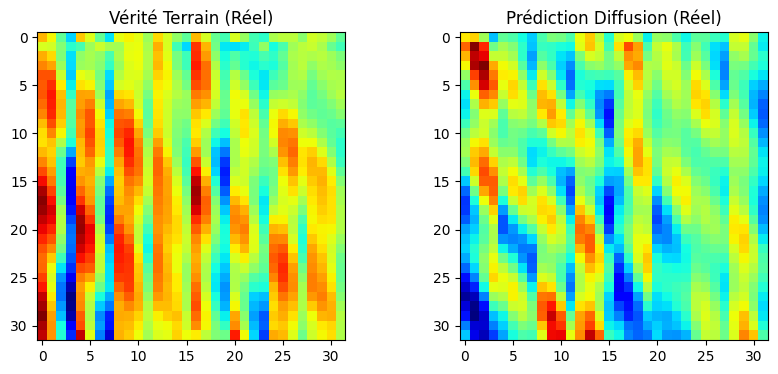

In [23]:
import matplotlib.pyplot as plt

# Test sur un échantillon
encoder.eval()
unet.eval()

# Charger le set de test
test_ds = CSIDataset("./../Data_format/X_test.npy", "./../Data_format/Y_test.npy")
x_test, y_true = test_ds[0]
x_test = x_test.unsqueeze(0).to(device)

# Prédiction par diffusion (10 étapes de débruitage)
with torch.no_grad():
    y_pred = predict_csi(encoder, unet, x_test, n_steps=10)
    y_pred = y_pred.squeeze().cpu().numpy()

# Affichage de la partie réelle (canal 0)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(y_true[0], cmap='jet')
plt.title("Vérité Terrain (Réel)")
plt.subplot(1, 2, 2)
plt.imshow(y_pred[0], cmap='jet')
plt.title("Prédiction Diffusion (Réel)")
plt.show()

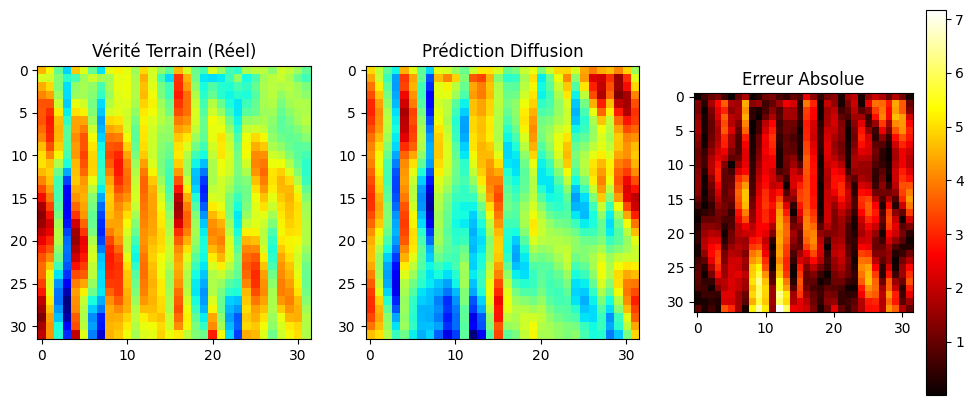

In [24]:
import matplotlib.pyplot as plt

# 1. Préparation d'un échantillon de test
test_ds = CSIDataset("./../Data_format/X_test.npy", "./../Data_format/Y_test.npy")
x_test, y_true = test_ds[0] # On prend le premier exemple
x_test = x_test.unsqueeze(0).to(device)

# 2. Inférence (Génération du futur)
with torch.no_grad():
    # On utilise 10 étapes de débruitage pour la vitesse
    y_pred = predict_csi(encoder, unet, x_test, n_steps=10)
    y_pred = y_pred.squeeze().cpu().numpy()
    y_true = y_true.numpy()

# 3. Affichage (Partie Réelle du Canal)
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.title("Vérité Terrain (Réel)")
plt.imshow(y_true[0], cmap='jet')

plt.subplot(1, 3, 2)
plt.title("Prédiction Diffusion")
plt.imshow(y_pred[0], cmap='jet')

plt.subplot(1, 3, 3)
plt.title("Erreur Absolue")
plt.imshow(np.abs(y_true[0] - y_pred[0]), cmap='hot')
plt.colorbar()
plt.show()

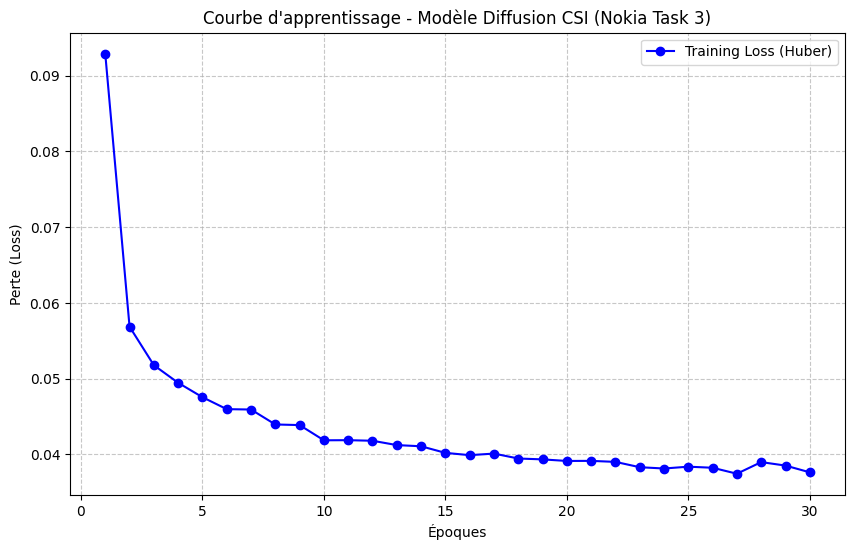

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Vecteur des pertes (Loss) extraites de tes logs
history_loss = [
    0.092898, 0.056861, 0.051774, 0.049451, 0.047550, 
    0.045971, 0.045921, 0.043948, 0.043868, 0.041858,
    0.041873, 0.041798, 0.041226, 0.041069, 0.040198,
    0.039896, 0.040104, 0.039454, 0.039338, 0.039130,
    0.039142, 0.039008, 0.038305, 0.038134, 0.038375,
    0.038232, 0.037445, 0.038979, 0.038520, 0.037629
]

epochs = range(1, len(history_loss) + 1)

# Création du graphique
plt.figure(figsize=(10, 6))
plt.plot(epochs, history_loss, 'b-o', label='Training Loss (Huber)')
plt.title('Courbe d\'apprentissage - Modèle Diffusion CSI (Nokia Task 3)')
plt.xlabel('Époques')
plt.ylabel('Perte (Loss)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Optionnel : Échelle logarithmique si tu veux mieux voir la fin de courbe
# plt.yscale('log')

plt.show()